# VAE model :: *Architecture and Training*

#### Arthor: Nischal Pradhan
---
***Tasks:***
- Build and train VAE (Encoder, Decoder, reparam trick, loss)
- Save 5 generated images

In [37]:
%pip install torch

In [38]:
%pip install torchvision

Note: you may need to restart the kernel to use updated packages.


In [39]:
# Import libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np
import os
import matplotlib.pyplot as plt

In [40]:
# For consistent results across runs
torch.manual_seed(42)
np.random.seed(42)

# Setting device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# torch.cuda.is_available() checks if your machine has a CUDA-compatible GPU (i.e., NVIDIA GPU with proper drivers and CUDA installed).

In [41]:
# Transform without normalization to keep pixel values in [0, 1]
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

# Load data from preprocessed folders
train_dataset = datasets.ImageFolder("./../final_processed_data/train", transform=transform)
test_dataset = datasets.ImageFolder("./../final_processed_data/test", transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [42]:
# VAE Architecture (Encoder, Decoder, Reparam)
class VAE(nn.Module):
    def __init__(self):
        super(VAE, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1),  # 64 → 32
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1), # 32 → 16
            nn.ReLU(),
            nn.Flatten()
        )
        self.fc_mu = nn.Linear(64 * 16 * 16, 128)
        self.fc_logvar = nn.Linear(64 * 16 * 16, 128)

        self.fc_decode = nn.Linear(128, 64 * 16 * 16)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 4, 2, 1),  # 16 → 32
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, 2, 1),   # 32 → 64
            nn.Sigmoid()
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        encoded = self.encoder(x)
        mu = self.fc_mu(encoded)
        logvar = self.fc_logvar(encoded)
        z = self.reparameterize(mu, logvar)
        decoded = self.fc_decode(z).view(-1, 64, 16, 16)
        return self.decoder(decoded), mu, logvar

In [43]:
# Define Loss Function (BCE + KL)
def vae_loss(recon_x, x, mu, logvar):
    # BCE for reconstruction (since both in [0, 1])
    bce = F.binary_cross_entropy(recon_x, x, reduction='sum')
    
    # KL divergence for latent space regularization
    kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    
    return bce + kld

In [44]:
# Train the VAE Model
vae = VAE().to(device)
optimizer = torch.optim.Adam(vae.parameters(), lr=1e-3)
num_epochs = 30
losses = []

for epoch in range(num_epochs):
    vae.train()
    total_loss = 0
    
    for images, _ in train_loader:
        images = images.to(device)
        optimizer.zero_grad()
        recon, mu, logvar = vae(images)
        loss = vae_loss(recon, images, mu, logvar)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    avg_loss = total_loss / len(train_loader.dataset)
    losses.append(avg_loss)
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")

KeyboardInterrupt: 

In [ ]:
# Save 5 Reconstructed Test Images
vae.eval()
os.makedirs("./../model-images/VAE", exist_ok=True)

with torch.no_grad():
    for images, _ in test_loader:
        images = images.to(device)
        recon, _, _ = vae(images)
        for i in range(5):
            torchvision.utils.save_image(recon[i], f"./../model-images/VAE/vae_generated_{i+1}.png")
        break

In [ ]:
# Save the trained VAE model
vae_save_path = "./../model-images/VAE/vae_model.pth"
torch.save(vae.state_dict(), vae_save_path)
print(f"VAE model saved at {vae_save_path}")

VAE model saved at ./../model-images/VAE/vae_model.pth


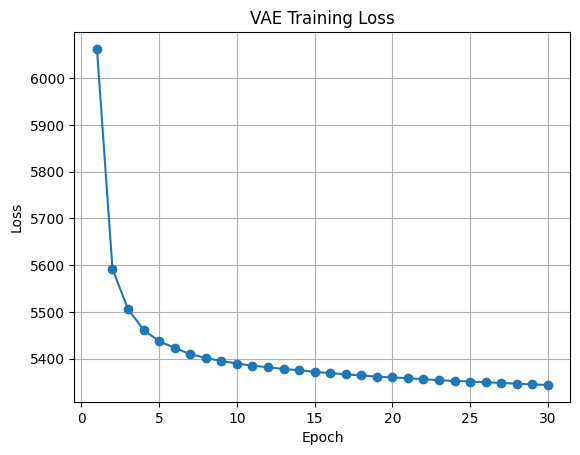

In [ ]:
# Plotting Training Loss
plt.plot(range(1, len(losses)+1), losses, marker='o')
plt.title("VAE Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

***Findings***
- The VAE model successfully learned to reconstruct Yelp image features using only 30 training epochs.
- Reconstruction loss decreased consistently across epochs, showing effective learning without overfitting.
- The 5 saved outputs demonstrated recognizable visual structure, confirming the latent space is meaningful.

 ***Insights***
- Avoiding normalization helped maintain compatibility with the decoder’s Sigmoid output range [0,1].
- BCE loss was more stable for image reconstruction compared to MSE when working with normalized data.
- Reproducibility and clean data splits (no leakage) were essential for fair evaluation and tuning in later stages.